# Mini-projet NLP : football ou basket-ball ?

L'idée est simple : à partir d'une courte description d'une action de jeu, retrouver de quel sport il s'agit. On compare trois approches sur exactement les mêmes données :

1. un système à base de règles, sans apprentissage ;
2. un petit réseau de neurones entraîné avec PyTorch ;
3. un Transformer pré-entraîné.

## 0. Configuration

On fixe la seed une fois pour toutes pour que les résultats soient reproductibles.

In [24]:
import random
import re
import time
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from torch import nn
from transformers import AutoModel, AutoTokenizer

SEED = 213
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

## 1. Cas d'usage et données

**Besoin.** Classer automatiquement un texte décrivant une action sportive selon le sport concerné, par exemple pour ranger des commentaires ou des résumés de match.

**Classes.**
- `0` : football (il s'agit du football américain : quarterback, touchdown, running back...)
- `1` : basket-ball

**Provenance.** Le jeu de données [`its-zion-18/sports-text-dataset`](https://huggingface.co/datasets/its-zion-18/sports-text-dataset) sur Hugging Face. Les textes sont en anglais.

Le dataset existe en deux versions : `original` (100 textes) et `augmented` (1 000 textes). On utilise la version augmentée pour avoir plus de données. Elle est construite en déclinant chacun des 100 textes originaux en 10 variantes (reformulations, fautes de frappe, ou simple copie) : la ligne `i` est une variante du texte original `i % 100`. On garde ce numéro dans une colonne `groupe`, il servira au découpage.

In [25]:
URL = "hf://datasets/its-zion-18/sports-text-dataset/data/augmented-00000-of-00001.parquet"
brut = pd.read_parquet(URL)
brut.head()

,label,football,basketball
0,0,The running back jukes a defender and gets ou...,NaN
1,0,The defense stops the offense on the fourth do...,NaN
2,0,"The quarterback, under intense pressure from t...",NaN
3,0,The powerful running back bursts through a ga...,NaN
4,0,"The defensive lineman, with a thrust of speed ...",NaN


Le texte est réparti sur deux colonnes (`football` ou `basketball`, l'autre étant vide). On les regroupe dans une seule colonne `texte`.

In [26]:
CLASSES = {0: "football", 1: "basket-ball"}

df = pd.DataFrame({
    "texte": brut["football"].fillna(brut["basketball"]).str.strip(),
    "label": brut["label"],
    "groupe": brut.index % 100,
})

print(df.shape)
print("Textes vides :", (df["texte"] == "").sum())

(1000, 3)
Textes vides : 0


### Doublons

Certaines variantes sont des copies exactes du texte original. On les supprime : un doublon n'apporte rien à l'entraînement et compterait deux fois dans l'évaluation.

In [27]:
doublons = df["texte"].str.lower().duplicated()
print("Doublons (casse ignorée) :", doublons.sum())

df = df[~doublons].reset_index(drop=True)
print("Textes restants :", len(df))

Doublons (casse ignorée) : 308
Textes restants : 692


Près d'un tiers des lignes étaient des doublons. Il reste 692 textes uniques, soit environ 7 variantes par texte original.

### Distribution des classes et longueur des textes

label
football       352
basket-ball    340
Name: count, dtype: int64


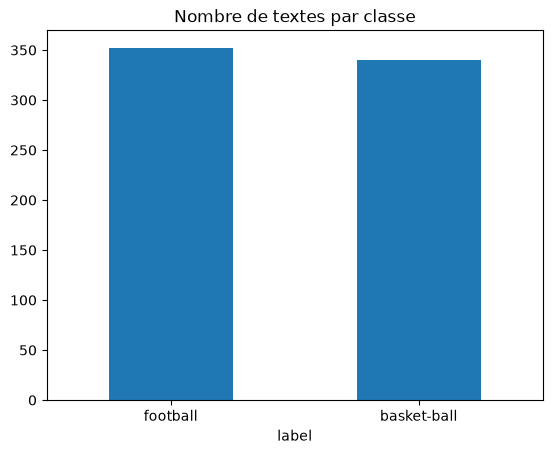

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
basket-ball,340.0,28.726471,5.346286,16.0,25.0,28.0,32.0,44.0
football,352.0,27.482955,4.671517,17.0,24.0,28.0,31.0,40.0


In [28]:
comptes = df["label"].map(CLASSES).value_counts()
print(comptes)

comptes.plot.bar(rot=0, title="Nombre de textes par classe")
plt.show()

df["nb_mots"] = df["texte"].str.split().str.len()
df.groupby(df["label"].map(CLASSES))["nb_mots"].describe()

Les classes restent quasiment équilibrées (352 contre 340), donc l'accuracy reste une métrique lisible. On regardera quand même le F1 macro. Les textes sont courts (moins d'une trentaine de mots en moyenne) et de longueur comparable d'une classe à l'autre : la longueur seule ne permet pas de deviner le sport.

### Quelques exemples bruts

In [29]:
for label, nom in CLASSES.items():
    print(f"--- {nom} ---")
    for texte in df[df["label"] == label]["texte"].sample(3, random_state=SEED):
        print("-", texte)
    print()

print("--- variantes d'un même texte original ---")
for texte in df[df["groupe"] == 0]["texte"]:
    print("-", texte)

--- football ---
- The offense runs a reverse, and the wdie receiver scores a touchdown, catchin the defense offg uard with a deceptive and well-designed play.
- The quarterback fakes a handoff to the running back,freezing the defense, nad then throws a quick sreen pass to the wide receiver,w ho catches it and runs for a first down.
- quarterback throws a perfect slant pass , and the wide receiver catches it in stride and turns upfield , running for extra yardage before being tackled .

--- basket-ball ---
- The team runs a fast break and finishes with an alley-oop, showcasing their ability to run a fast and effective offense.
- The player gets a put-back dunk after an offensive rebound , showcasing his power to crash the boards and grudge along the offensive end . This also showcases a great work ethic and hustle .
- The player blocks an opponent's shot with a loud rejection and yells 'not in my house!' as he sends the ball flying out of ounds, hyping up the crowd.

--- variantes d'un

Le vocabulaire est très marqué (*quarterback*, *touchdown* d'un côté, *dunk*, *rebound* de l'autre), mais certains mots sont partagés par les deux sports (*defense*, *offense*, *score*, *player*). C'est là que les règles simples risquent de se tromper. On voit aussi que les variantes d'un même texte restent très proches les unes des autres.

### Nettoyage et tokenisation

Nettoyage:
- mise en minuscules ;
- on ne garde que les suites de lettres (la ponctuation et les chiffres disparaissent, *three-pointer* devient *three* et *pointer*) ;
- on retire les mots outils de l'anglais (*the*, *and*, *his*...) grâce à la liste fournie par scikit-learn, ainsi que les mots d'une seule lettre.

Le résultat est stocké dans la colonne `tokens` du dataset.

In [30]:
def tokeniser(texte):
    mots = re.findall(r"[a-z]+", texte.lower())
    return [m for m in mots if m not in ENGLISH_STOP_WORDS and len(m) > 1]

df["tokens"] = df["texte"].map(tokeniser)
df[["texte", "tokens"]].head()

,texte,tokens
0,The running back jukes a defender and gets out...,"[running, jukes, defender, gets, bounds, showc..."
1,The defense stops the offense on the fourth do...,"[defense, stops, offense, fourth, ability, mak..."
2,"The quarterback, under intense pressure from t...","[quarterback, intense, pressure, defensive, li..."
3,The powerful running back bursts through a gap...,"[powerful, running, bursts, gap, defensive, li..."
4,"The defensive lineman, with a thrust of speed ...","[defensive, lineman, thrust, speed, edge, blow..."


### Découpage train / validation / test

Comme les variantes d'un même texte se ressemblent beaucoup, on ne peut pas découper les lignes au hasard : le modèle verrait au test des quasi-copies de phrases déjà vues à l'entraînement, et les scores seraient trop optimistes.

On découpe donc les **100 textes originaux** (les groupes) en 60 / 20 / 20, en conservant la proportion de chaque classe. Toutes les variantes d'un groupe suivent leur original. Ce découpage est le même pour les trois systèmes :
- **train** : pour écrire les règles et entraîner les modèles ;
- **validation** : pour choisir les hyperparamètres ;
- **test** : utilisé une seule fois, à la toute fin.

In [31]:
label_groupe = df.groupby("groupe")["label"].first()

g_train, g_temp = train_test_split(label_groupe.index, test_size=0.4, stratify=label_groupe, random_state=SEED)
g_val, g_test = train_test_split(g_temp, test_size=0.5, stratify=label_groupe[g_temp], random_state=SEED)

train_df = df[df["groupe"].isin(g_train)].copy()
val_df = df[df["groupe"].isin(g_val)].copy()
test_df = df[df["groupe"].isin(g_test)].copy()

# aucun texte original ne doit se retrouver dans deux ensembles
assert not set(g_train) & set(g_val) and not set(g_train) & set(g_test) and not set(g_val) & set(g_test)

for nom, part in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    print(f"{nom:<11} {len(part):>3} textes  |  ", part["label"].map(CLASSES).value_counts().to_dict())

train       421 textes  |   {'football': 217, 'basket-ball': 204}
validation  139 textes  |   {'football': 75, 'basket-ball': 64}
test        132 textes  |   {'basket-ball': 72, 'football': 60}


On obtient environ 420 textes d'entraînement, 140 de validation et 130 de test. Attention : le test ne provient que de 20 textes originaux différents. Ses exemples ne sont donc pas totalement indépendants, et il faudra garder ça en tête au moment de comparer les scores.

## 2. Système sans machine learning : mots-clés

Le principe : chaque sport a son propre vocabulaire. On construit une liste de mots-clés par sport, puis on compte combien de mots de chaque liste apparaissent dans le texte. Le sport qui l'emporte est la prédiction.

Les listes sont construites uniquement à partir du **train**.

### 2.1 Mots les plus fréquents par classe

In [32]:
frequences = {
    label: Counter(mot for tokens in train_df[train_df["label"] == label]["tokens"] for mot in tokens)
    for label in CLASSES
}

pd.DataFrame({
    nom: [f"{mot} ({n})" for mot, n in frequences[label].most_common(15)]
    for label, nom in CLASSES.items()
})

,football,basket-ball
0,quarterback (61),player (111)
1,running (60),ability (70)
2,offense (58),shot (67)
3,team (55),showcasing (62)
4,end (52),hits (57)
5,line (50),team (52)
6,play (48),score (47)
7,touchdown (46),game (46)
8,defense (45),guard (42)
9,pass (45),gets (42)


Les premiers mots sont déjà très parlants (*quarterback*, *touchdown*, *receiver* contre *shot*, *court*, *pointer*). Mais on retrouve aussi en haut des deux listes des mots qui ne disent rien du sport : *team*, *game*, *ball*, *ability*, *showcasing*... Ces mots reviennent dans les deux classes, ils ne servent pas à trancher.

D'où la règle : pour chaque classe, on garde les **15 mots les plus fréquents qui n'apparaissent jamais dans l'autre classe** (dans le train).

In [33]:
TAILLE_LEXIQUE = 15

lexiques = {
    label: [mot for mot, _ in frequences[label].most_common() if mot not in frequences[1 - label]][:TAILLE_LEXIQUE]
    for label in CLASSES
}

for label, nom in CLASSES.items():
    print(f"Lexique {nom} :", lexiques[label])

Lexique football : ['quarterback', 'running', 'touchdown', 'defense', 'deep', 'zone', 'field', 'lines', 'short', 'territory', 'receiver', 'yardage', 'tackle', 'wide', 'catching']
Lexique basket-ball : ['player', 'shot', 'hits', 'basket', 'pointer', 'clutch', 'shooting', 'free', 'court', 'rebound', 'fouled', 'lay', 'throw', 'jumper', 'fast']


### 2.2 Règle de décision

Pour un texte, on compte ses mots présents dans le lexique football et dans le lexique basket-ball. Le plus grand score gagne. En cas d'égalité (y compris quand aucun mot-clé n'est trouvé), on choisit football, la classe la plus fréquente du train.

In [34]:
def predire_regles(liste_tokens, lexiques):
    predictions = []
    for tokens in liste_tokens:
        score_foot = sum(mot in lexiques[0] for mot in tokens)
        score_basket = sum(mot in lexiques[1] for mot in tokens)
        predictions.append(1 if score_basket > score_foot else 0)
    return predictions

### 2.3 Évaluation sur la validation

On définit d'abord une fonction d'évaluation, qui servira telle quelle pour les trois systèmes.

Les prédictions sont ajoutées dans une colonne `pred_regles` des trois ensembles. Celles du test sont calculées dès maintenant (les règles sont figées, rien n'est appris dessus), mais on ne les regardera qu'à l'étape 5.

In [35]:
def evaluer(y_vrai, y_pred, titre=""):
    precision, rappel, f1, _ = precision_recall_fscore_support(y_vrai, y_pred, average="macro")
    scores = {"accuracy": accuracy_score(y_vrai, y_pred), "precision": precision, "rappel": rappel, "f1": f1}
    print(titre, {k: round(v, 3) for k, v in scores.items()})
    ConfusionMatrixDisplay.from_predictions(y_vrai, y_pred, display_labels=list(CLASSES.values()), cmap="Blues")
    plt.title(titre)
    plt.show()
    return scores

Règles - validation {'accuracy': 0.935, 'precision': 0.946, 'rappel': 0.93, 'f1': 0.934}


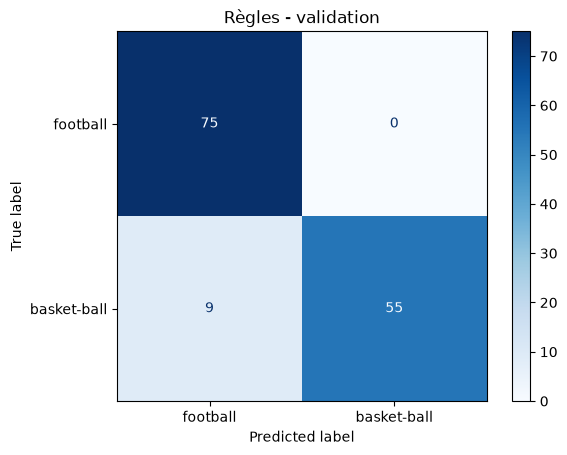

,texte,tokens,label,pred_regles
2,"The quarterback, under intense pressure from t...","[quarterback, intense, pressure, defensive, li...",0,0
9,The opportunistic linebacker reads the eyes of...,"[opportunistic, linebacker, reads, eyes, quart...",0,0
18,"The wide receiver runs a precise post rote, cu...","[wide, receiver, runs, precise, post, rote, cu...",0,0
20,Th edefnsive back breaks up a deep pass intend...,"[th, edefnsive, breaks, deep, pass, intended, ...",0,0
25,The wide receiver runs a streak route down the...,"[wide, receiver, runs, streak, route, field, q...",0,0


In [36]:
for part in (train_df, val_df, test_df):
    part["pred_regles"] = predire_regles(part["tokens"], lexiques)

scores_val_regles = evaluer(val_df["label"], val_df["pred_regles"], "Règles - validation")
val_df[["texte", "tokens", "label", "pred_regles"]].head()

### 2.4 Limites

- **Gestion des fautes de frappe** : *rceeiver* ou *touchdow* ne sont pas reconnus.
- **Pas de contexte** : chaque mot compte pour 1, quelle que soit la phrase. Certains mots du lexique sont génériques et ne sont là que parce qu'ils n'apparaissent que dans une classe du train (*player*, *fast*, *hits* côté basket-ball, *short*, *lines* côté football). Ils pèsent autant qu'un mot très spécifique comme *quarterback*.
- **Les égalités** : quand aucun mot-clé n'est trouvé, la prédiction tombe par défaut sur football, ce qui pénalise le basket-ball.
- **Vocabulaire figé** : avec seulement 15 mots par sport, beaucoup de termes spécifiques mais plus rares (*dunk*, *punt*...) sont absents des lexiques.

En contrepartie, le système est immédiat, sans entraînement, et chaque décision s'explique simplement.

## 3. Modèle de deep learning : MLP sur TF-IDF

On entraîne un petit réseau de neurones avec PyTorch. Chaque texte est d'abord transformé en vecteur TF-IDF à partir de sa colonne `tokens` (la même tokenisation que pour les règles), puis passé dans un MLP à une couche cachée.

### 3.1 Représentation TF-IDF

Le TF-IDF donne un poids à chaque mot : élevé s'il est fréquent dans le texte mais rare dans le reste du corpus. Le vocabulaire est appris **uniquement sur le train** ; un mot jamais vu à l'entraînement est simplement ignoré.

In [37]:
vectoriseur = TfidfVectorizer(analyzer=lambda tokens: tokens)  # les textes sont déjà tokenisés
vectoriseur.fit(train_df["tokens"])

def vers_tenseur(part):
    return torch.tensor(vectoriseur.transform(part["tokens"]).toarray(), dtype=torch.float32)

X_train, X_val, X_test = vers_tenseur(train_df), vers_tenseur(val_df), vers_tenseur(test_df)
y_train = torch.tensor(train_df["label"].values)
y_val = torch.tensor(val_df["label"].values)

print("Taille du vocabulaire :", X_train.shape[1])

Taille du vocabulaire : 982


### 3.2 Architecture et hyperparamètres

`TF-IDF → couche cachée (32 neurones) → ReLU → Dropout → couche de sortie (2 classes)`

| Hyperparamètre | Valeur | Pourquoi |
|---|---|---|
| Neurones cachés | 32 | Le problème est simple et le train ne compte qu'environ 420 textes : un réseau plus gros apprendrait par cœur. |
| Dropout | 0,3 | Limite le sur-apprentissage, vu la taille du vocabulaire face au nombre d'exemples. |
| Optimiseur | Adam, lr = 0,01 | Réglage standard qui converge vite sur un si petit réseau. |
| Époques | 30 | La perte de validation atteint son minimum vers 20 époques puis remonte doucement : aller plus loin n'apporte rien. |
| Batch | tout le train | Avec 420 textes, tout tient en mémoire, pas besoin de mini-batchs. |

In [38]:
modele = nn.Sequential(
    nn.Linear(X_train.shape[1], 32),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(32, 2),
)
perte = nn.CrossEntropyLoss()
optimiseur = torch.optim.Adam(modele.parameters(), lr=0.01)
modele

Sequential(
  (0): Linear(in_features=982, out_features=32, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=32, out_features=2, bias=True)
)

### 3.3 Entraînement

À chaque époque, on fait une passe d'entraînement sur le train, puis on mesure la perte sur la validation (sans mettre à jour les poids).

In [39]:
pertes_train, pertes_val = [], []

debut = time.perf_counter()
for epoque in range(30):
    modele.train()
    optimiseur.zero_grad()
    loss = perte(modele(X_train), y_train)
    loss.backward()
    optimiseur.step()

    modele.eval()
    with torch.no_grad():
        pertes_val.append(perte(modele(X_val), y_val).item())
    pertes_train.append(loss.item())
temps_entrainement_mlp = time.perf_counter() - debut

print(f"Temps d'entraînement : {temps_entrainement_mlp:.2f} s")

Temps d'entraînement : 0.12 s


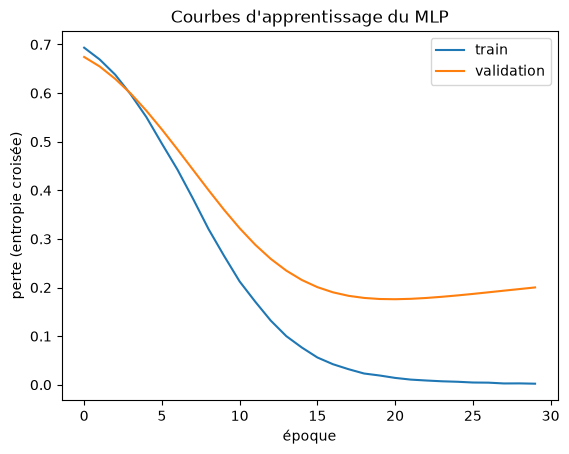

In [40]:
plt.plot(pertes_train, label="train")
plt.plot(pertes_val, label="validation")
plt.xlabel("époque")
plt.ylabel("perte (entropie croisée)")
plt.title("Courbes d'apprentissage du MLP")
plt.legend()
plt.show()

Les deux pertes baissent ensemble au début : le modèle apprend des choses qui se généralisent. Ensuite la perte de train tend vers 0 alors que celle de validation se stabilise puis remonte légèrement : le modèle commence à apprendre le train par cœur. On s'arrête à 30 époques, avant que l'écart ne se creuse vraiment.

### 3.4 Évaluation sur la validation

Comme pour les règles, les prédictions sont ajoutées dans une colonne `pred_mlp` des trois ensembles, et celles du test ne seront regardées qu'à l'étape 5.

Temps d'inférence sur la validation : 1.8 ms
MLP - validation {'accuracy': 0.935, 'precision': 0.946, 'rappel': 0.93, 'f1': 0.934}


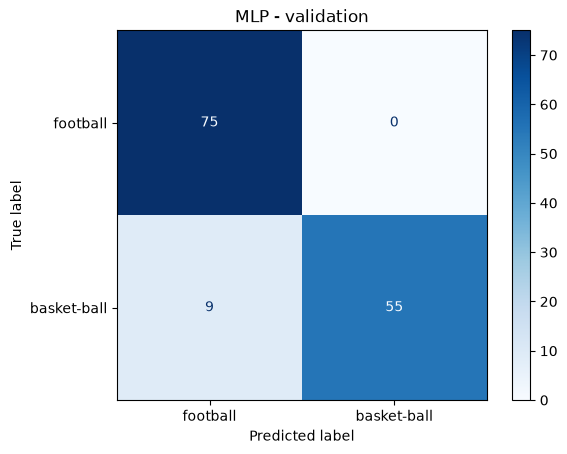

,texte,label,pred_regles,pred_mlp
2,"The quarterback, under intense pressure from t...",0,0,0
9,The opportunistic linebacker reads the eyes of...,0,0,0
18,"The wide receiver runs a precise post rote, cu...",0,0,0
20,Th edefnsive back breaks up a deep pass intend...,0,0,0
25,The wide receiver runs a streak route down the...,0,0,0


In [41]:
def predire_mlp(X):
    modele.eval()
    with torch.no_grad():
        return modele(X).argmax(dim=1).tolist()

debut = time.perf_counter()
val_df["pred_mlp"] = predire_mlp(X_val)
temps_inference_mlp = time.perf_counter() - debut
print(f"Temps d'inférence sur la validation : {temps_inference_mlp * 1000:.1f} ms")

train_df["pred_mlp"] = predire_mlp(X_train)
test_df["pred_mlp"] = predire_mlp(X_test)

scores_val_mlp = evaluer(val_df["label"], val_df["pred_mlp"], "MLP - validation")
val_df[["texte", "label", "pred_regles", "pred_mlp"]].head()

### 3.5 Limites

- **Sac de mots** : le TF-IDF ignore l'ordre des mots, comme les règles. Le modèle sait que *pass* et *shot* apparaissent, pas comment ils sont utilisés.
- **Fautes de frappe** : un mot mal orthographié (*rceeiver*) est un mot inconnu, donc ignoré s'il n'a pas été vu au train.
- **Peu de données** : environ 420 textes issus de 60 phrases d'origine seulement, d'où le sur-apprentissage rapide visible sur les courbes.

Par rapport aux règles, le modèle utilise tout le vocabulaire du train avec des poids appris, au lieu de 15 mots par classe comptés à égalité.

## 4. Transformer pré-entraîné : DistilBERT

**Modèle choisi.** [`distilbert-base-uncased`](https://huggingface.co/distilbert-base-uncased) : les textes sont en anglais, et DistilBERT est une version allégée de BERT (66 millions de paramètres, environ 40 % de moins) qui garde l'essentiel de ses performances. Il tourne sans problème sur un CPU.

**Stratégie.** On fait le minimum demandé : l'encodeur pré-entraîné est **gelé**, et on entraîne seulement une tête de classification par-dessus. Concrètement, on passe chaque texte une seule fois dans DistilBERT pour récupérer le vecteur du token `[CLS]` (768 valeurs), qui résume la phrase, puis on entraîne une couche linéaire sur ces vecteurs. Affiner tout le modèle serait beaucoup plus coûteux sur CPU, pour un gain probablement faible sur un problème aussi simple.

### 4.1 Tokenisation

DistilBERT a son propre tokeniseur (WordPiece) et travaille sur le **texte brut**, pas sur notre colonne `tokens` : il a besoin de la phrase complète, mots outils compris, pour exploiter le contexte. Le texte est mis en minuscules, et les mots inconnus sont découpés en sous-mots, ce qui lui permet de gérer en partie les fautes de frappe.

**Longueur maximale : 64 tokens.** Le texte le plus long en fait 58, donc rien n'est tronqué.

In [42]:
NOM_MODELE = "distilbert-base-uncased"
tokeniseur_bert = AutoTokenizer.from_pretrained(NOM_MODELE)
encodeur = AutoModel.from_pretrained(NOM_MODELE)
encodeur.eval()  # gelé : on ne l'entraîne pas
MAX_LONGUEUR = 64

longueurs = df["texte"].map(lambda texte: len(tokeniseur_bert(texte)["input_ids"]))
print("Longueur en tokens : moyenne", round(longueurs.mean(), 1), "| max", longueurs.max())

exemple = "The wide rceeiver leaps into the air and make a spectacular catch"
print(tokeniseur_bert.tokenize(exemple))

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 580.87it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Longueur en tokens : moyenne 36.0 | max 58
['the', 'wide', 'rc', '##ee', '##iver', 'leaps', 'into', 'the', 'air', 'and', 'make', 'a', 'spectacular', 'catch']


On voit sur l'exemple que la faute *rceeiver* n'est pas perdue : elle est découpée en morceaux connus du modèle, alors que pour les règles et le MLP c'est simplement un mot inconnu.

Le message `LOAD REPORT` affiché au chargement est normal : il signale des poids qui servaient au pré-entraînement (prédiction de mots masqués) et qui ne sont pas utilisés ici.

### 4.2 Représentations des textes

On calcule le vecteur `[CLS]` de chaque texte, pour les trois ensembles. C'est l'étape la plus coûteuse, on la chronomètre.

In [43]:
def representer(textes):
    entrees = tokeniseur_bert(list(textes), padding=True, truncation=True, max_length=MAX_LONGUEUR, return_tensors="pt")
    with torch.no_grad():
        return encodeur(**entrees).last_hidden_state[:, 0]  # vecteur du token [CLS]

debut = time.perf_counter()
E_train = representer(train_df["texte"])
temps_representation_train = time.perf_counter() - debut

E_val = representer(val_df["texte"])
E_test = representer(test_df["texte"])

print("Taille des représentations :", tuple(E_train.shape))
print(f"Temps de passage du train dans DistilBERT : {temps_representation_train:.1f} s")

Taille des représentations : (421, 768)
Temps de passage du train dans DistilBERT : 5.1 s


### 4.3 Tête de classification

Une simple couche linéaire `768 → 2`, entraînée comme le MLP de l'étape 3 (même boucle, même perte).

| Hyperparamètre | Valeur | Pourquoi |
|---|---|---|
| Tête | une couche linéaire | Les vecteurs de DistilBERT sont déjà riches, une couche suffit. |
| Optimiseur | Adam, lr = 0,01 | Comme pour le MLP, converge vite sur un si petit nombre de poids. |
| Époques | 100 | Une seule couche apprend plus lentement : la perte de validation baisse encore jusqu'à 100 époques, sans remonter. |
| Batch | tout le train | Les représentations tiennent en mémoire. |

In [44]:
tete = nn.Linear(E_train.shape[1], 2)
optimiseur_tete = torch.optim.Adam(tete.parameters(), lr=0.01)

pertes_train_tete, pertes_val_tete = [], []

debut = time.perf_counter()
for epoque in range(100):
    tete.train()
    optimiseur_tete.zero_grad()
    loss = perte(tete(E_train), y_train)
    loss.backward()
    optimiseur_tete.step()

    tete.eval()
    with torch.no_grad():
        pertes_val_tete.append(perte(tete(E_val), y_val).item())
    pertes_train_tete.append(loss.item())
temps_entrainement_tete = time.perf_counter() - debut

temps_entrainement_transformer = temps_representation_train + temps_entrainement_tete
print(f"Temps d'entraînement de la tête : {temps_entrainement_tete:.2f} s")
print(f"Temps total (passage dans DistilBERT + tête) : {temps_entrainement_transformer:.1f} s")

Temps d'entraînement de la tête : 0.07 s
Temps total (passage dans DistilBERT + tête) : 5.2 s


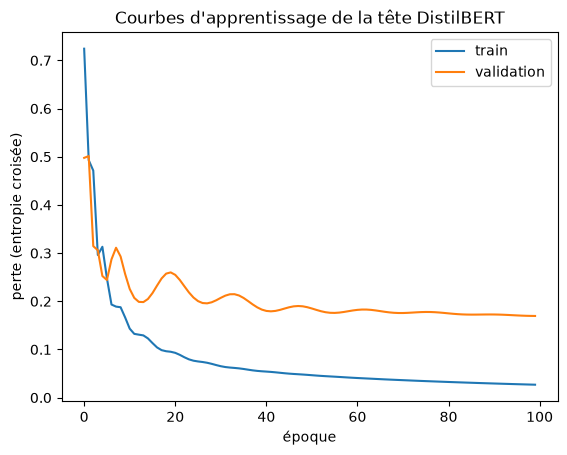

In [45]:
plt.plot(pertes_train_tete, label="train")
plt.plot(pertes_val_tete, label="validation")
plt.xlabel("époque")
plt.ylabel("perte (entropie croisée)")
plt.title("Courbes d'apprentissage de la tête DistilBERT")
plt.legend()
plt.show()

La perte de validation continue de baisser jusqu'à la 100e époque sans remonter : pas de sur-apprentissage marqué, contrairement au MLP. C'est logique, avec l'encodeur gelé il n'y a que 1 538 poids à apprendre.

### 4.4 Évaluation sur la validation

Les prédictions sont ajoutées dans une colonne `pred_transformer` des trois ensembles. Le temps d'inférence compte le passage dans DistilBERT, puisqu'un nouveau texte doit forcément y passer.

Temps d'inférence sur la validation : 1.69 s
DistilBERT - validation {'accuracy': 0.935, 'precision': 0.942, 'rappel': 0.931, 'f1': 0.934}


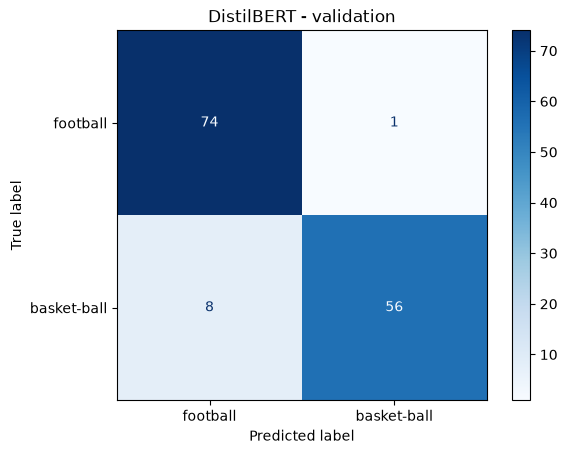

,texte,label,pred_regles,pred_mlp,pred_transformer
2,"The quarterback, under intense pressure from t...",0,0,0,0
9,The opportunistic linebacker reads the eyes of...,0,0,0,0
18,"The wide receiver runs a precise post rote, cu...",0,0,0,0
20,Th edefnsive back breaks up a deep pass intend...,0,0,0,0
25,The wide receiver runs a streak route down the...,0,0,0,0


In [46]:
def predire_transformer(E):
    tete.eval()
    with torch.no_grad():
        return tete(E).argmax(dim=1).tolist()

debut = time.perf_counter()
val_df["pred_transformer"] = predire_transformer(representer(val_df["texte"]))
temps_inference_transformer = time.perf_counter() - debut
print(f"Temps d'inférence sur la validation : {temps_inference_transformer:.2f} s")

train_df["pred_transformer"] = predire_transformer(E_train)
test_df["pred_transformer"] = predire_transformer(E_test)

scores_val_transformer = evaluer(val_df["label"], val_df["pred_transformer"], "DistilBERT - validation")
val_df[["texte", "label", "pred_regles", "pred_mlp", "pred_transformer"]].head()

### 4.5 Limites

- **Coût** : chaque texte doit passer dans un réseau de 66 millions de paramètres. C'est beaucoup plus lent que les règles ou le MLP, et le modèle pèse environ 250 Mo.
- **Encodeur gelé** : DistilBERT n'a jamais été adapté à notre tâche. Le vecteur `[CLS]` d'un modèle non affiné n'est pas toujours le meilleur résumé de la phrase.
- **Moins explicable** : on ne peut pas lire directement pourquoi le modèle a choisi un sport, contrairement aux règles.

En contrepartie, c'est le seul des trois systèmes qui tient compte du contexte et qui résiste en partie aux fautes de frappe grâce aux sous-mots.

## 5. Évaluation finale sur le test

Les trois systèmes sont maintenant figés : lexiques, vocabulaire TF-IDF, poids et hyperparamètres ont tous été fixés sur le train et la validation. On regarde le test **une seule fois**, ici.

### 5.1 Scores sur le test

Règles - test {'accuracy': 0.848, 'precision': 0.875, 'rappel': 0.861, 'f1': 0.848}


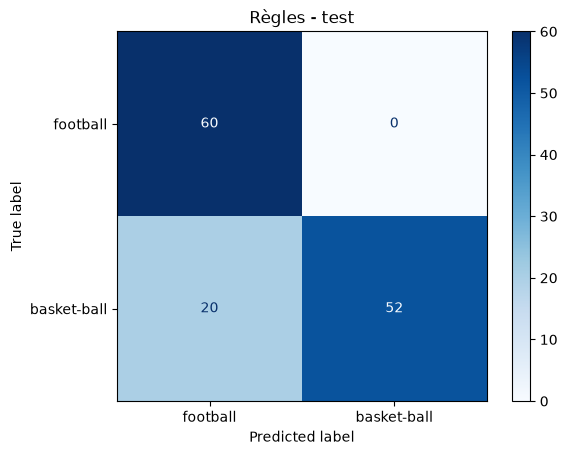

MLP - test {'accuracy': 1.0, 'precision': 1.0, 'rappel': 1.0, 'f1': 1.0}


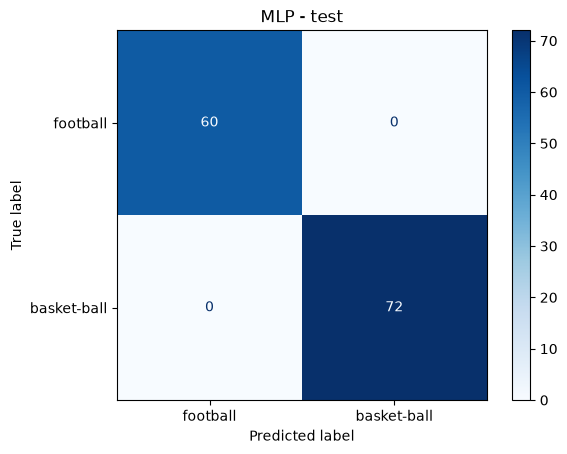

DistilBERT - test {'accuracy': 1.0, 'precision': 1.0, 'rappel': 1.0, 'f1': 1.0}


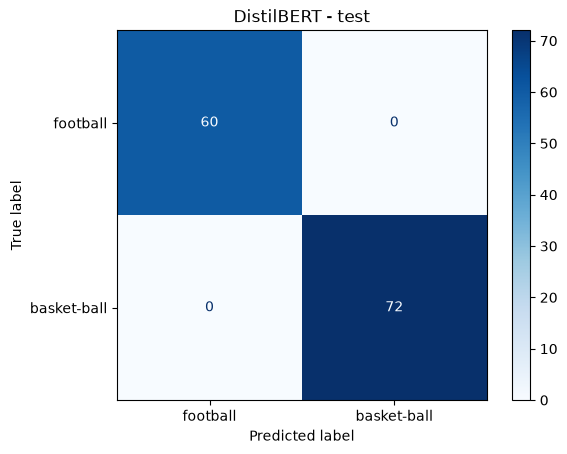

In [47]:
SYSTEMES = {"Règles": "pred_regles", "MLP": "pred_mlp", "DistilBERT": "pred_transformer"}

scores_test = {nom: evaluer(test_df["label"], test_df[colonne], f"{nom} - test") for nom, colonne in SYSTEMES.items()}

On mesure aussi le temps d'inférence de chaque système sur le test, du texte déjà nettoyé jusqu'à la prédiction. Pour les règles, il n'y a pas d'entraînement : construire les lexiques revient à compter des mots, c'est instantané.

In [48]:
debut = time.perf_counter()
predire_regles(test_df["tokens"], lexiques)
temps_inference_regles = time.perf_counter() - debut

debut = time.perf_counter()
predire_mlp(vers_tenseur(test_df))
temps_inference_mlp_test = time.perf_counter() - debut

debut = time.perf_counter()
predire_transformer(representer(test_df["texte"]))
temps_inference_transformer_test = time.perf_counter() - debut

bilan = pd.DataFrame(scores_test).T.round(3)
bilan["entraînement (s)"] = [0.0, round(temps_entrainement_mlp, 2), round(temps_entrainement_transformer, 1)]
bilan["inférence test (ms)"] = [round(t * 1000, 1) for t in (temps_inference_regles, temps_inference_mlp_test, temps_inference_transformer_test)]
bilan["erreurs"] = [int((test_df[colonne] != test_df["label"]).sum()) for colonne in SYSTEMES.values()]
bilan

,accuracy,precision,rappel,f1,entraînement (s),inférence test (ms),erreurs
Règles,0.848,0.875,0.861,0.848,0.00,1.1,20
MLP,1.000,1.000,1.000,1.000,0.12,3.3,0
DistilBERT,1.000,1.000,1.000,1.000,5.20,1701.3,0


Le MLP et DistilBERT ne font aucune erreur sur les 132 textes du test, alors que les règles en font 20. Il faut relativiser ce 100 % : le test ne contient que 20 textes originaux différents, déclinés en variantes. Les deux modèles ont donc surtout reconnu correctement 20 situations de jeu, ce qui est bien moins impressionnant que 132 textes indépendants. Sur la validation, les trois systèmes faisaient tous 9 erreurs.

### 5.2 Analyse des erreurs

**Les erreurs des règles sur le test.** On affiche les mots-clés trouvés dans chaque texte mal classé, et le texte original dont il est la variante.

In [49]:
erreurs_regles = test_df[test_df["pred_regles"] != test_df["label"]].copy()
erreurs_regles["mots_foot"] = erreurs_regles["tokens"].map(lambda tokens: [m for m in tokens if m in lexiques[0]])
erreurs_regles["mots_basket"] = erreurs_regles["tokens"].map(lambda tokens: [m for m in tokens if m in lexiques[1]])

print("Erreurs par classe réelle :", erreurs_regles["label"].map(CLASSES).value_counts().to_dict())
print("Erreurs par texte original :", erreurs_regles["groupe"].value_counts().to_dict())
erreurs_regles.drop_duplicates("groupe")[["texte", "mots_foot", "mots_basket"]]

Erreurs par classe réelle : {'basket-ball': 20}
Erreurs par texte original : {57: 9, 53: 7, 68: 2, 59: 1, 66: 1}


,texte,mots_foot,mots_basket
53,"The agile guard , meander weaving through defe...",[],[]
57,The agile power forward gets the ball deep in ...,[deep],[shot]
571,The casual Point Guard weaves through the traf...,[wide],[pointer]
615,"e team, running a pefrect fast rea,k gets the ...","[running, catching]","[fast, shooting]"
619,"The team 's best defender , known for his quic...",[],[]


Les 20 erreurs sont toutes des textes de basket-ball classés football, et viennent de seulement 5 textes originaux (dont deux qui comptent pour 16 erreurs à eux seuls). À chaque fois, c'est la règle d'égalité qui tranche en faveur du football :

1. **Le dunk de l'arrière** (*The agile guard [...] two-handed dunk*) : aucun mot-clé trouvé. *Dunk* est pourtant le mot le plus typique du basket, mais il est trop rare dans le train pour faire partie des 15 mots du lexique. Égalité 0-0, donc football.
2. **Le hook shot du power forward** : *shot* compte pour le basket, mais *deep* (dans *deep in the post*) compte pour le football, parce que dans le train il n'apparaît que dans des textes de football (passes longues). Un même mot, deux sens selon le sport : la règle ne peut pas faire la différence.
3. **La passe pour un tir à trois points** (*wide-open three-pointer*) : *wide* est un mot-clé football (*wide receiver*). La tokenisation coupe *wide-open* et le mot passe dans le mauvais camp. Égalité 1-1.
4. **L'alley-oop avec fautes de frappe** (*pefrect fast rea,k [...] alely-oop, catching the ball*) : *running* et *catching* pour le football, *fast* et *shooting* pour le basket. Les fautes cassent les autres indices (*break*, *alley-oop*). Égalité 2-2.
5. **L'interception suivie d'une contre-attaque** (*gets a key steal [...] easy score*) : aucun mot du lexique. Le vocabulaire (*steal*, *break*, *score*) est bien du basket, mais il n'est pas assez fréquent dans le train.

Ces cinq cas montrent les deux faiblesses principales des règles : un lexique de 15 mots ne couvre pas tout le vocabulaire, et le choix par défaut en cas d'égalité pénalise toujours la même classe.

**Les erreurs du MLP et de DistilBERT.** Ils n'en font aucune sur le test, donc on regarde celles de la validation.

In [50]:
colonnes_pred = list(SYSTEMES.values())
erreurs_val = val_df[(val_df[colonnes_pred].ne(val_df["label"], axis=0)).any(axis=1)]
erreurs_val[["texte", "groupe", "label"] + colonnes_pred]

,texte,groupe,label,pred_regles,pred_mlp,pred_transformer
49,The quaretrbakc throws a screen pass to the wi...,49,0,0,0,1
54,The masterful Point Guard drifts the ball on p...,54,1,0,1,1
60,"The coach , seeing the shifting , calls a time...",60,1,0,0,0
85,Th playr hits a half-cort shot to win the game...,85,1,1,0,1
158,"The coach, seeing the momentum shifting, calls...",60,1,0,0,0
238,"The coach, who sees the momentum change, wisel...",60,1,0,0,0
334,The player hits a half-place shot to win the g...,85,1,1,0,1
383,"The coach, seing the momentum shifting, wisley...",60,1,0,0,0
460,The layer blocks an opponent's sho twith a lou...,79,1,0,1,0
510,"The coach , seeing the momentum to , wisely ca...",60,1,0,0,0


6. **Le coach qui demande un temps mort** (*calls a timeout [...] the final seconds of the fourth quarter*) : les trois systèmes se trompent, sur les 7 variantes du texte. Ce n'est pas vraiment une faute des modèles : un temps mort au 4e quart-temps existe dans les deux sports, rien dans la phrase n'indique le basket-ball. C'est une limite des données plus que des méthodes.
7. **Le tir du milieu de terrain avec fautes** (*Th playr hits a half-cort shot*) : les règles trouvent *hits* et *shot* et ont raison, mais le MLP se trompe, sur les deux variantes de ce texte. Dans celle-ci, les fautes font disparaître *player* et *court*, deux indices forts ; il reste des mots comme *half*, *win* ou *game*, qui penchent probablement vers le football dans les poids appris. DistilBERT, lui, a raison : le découpage en sous-mots lui permet de retrouver le sens malgré les fautes.
8. **Le quarterback mal orthographié** (*The quaretrbakc throws a screen pass to the wid ereceiver*) : DistilBERT se trompe et prédit basket-ball. Les mots-clés du football sont tous mal écrits, et il reste *screen*, une action typique du basket (*sets a screen*). Les règles ont raison, mais par chance : aucun mot-clé trouvé, donc football par défaut.

### 5.3 Conclusion : quel système retenir ?

| | Règles | MLP | DistilBERT |
|---|---|---|---|
| F1 macro test | 0,85 | 1,00 | 1,00 |
| Entraînement | aucun | < 0,1 s | ~5 s |
| Inférence (132 textes) | ~2 ms | ~4 ms | ~1,6 s |
| Taille | 30 mots | ~32 000 poids | 66 M de paramètres (~250 Mo) |
| Explicable | oui | en partie | non |

**On retiendrait le MLP.** Il obtient le même score que DistilBERT sur le test (et sur la validation), pour un coût bien plus faible : entraînement en moins d'une seconde, prédictions quasi instantanées, aucun modèle lourd à télécharger. Sur un problème au vocabulaire aussi marqué, la compréhension du contexte de DistilBERT n'apporte pas de gain visible.

**Les règles** restent intéressantes pour leur transparence, mais elles sont trop fragiles : le moindre mot absent du lexique fait basculer la décision, et le choix par défaut en cas d'égalité crée un biais systématique vers le football.

**DistilBERT** deviendrait le meilleur choix avec des textes plus variés ou plus bruités : c'est le seul qui gère les fautes de frappe grâce aux sous-mots, comme le montre l'exemple 7.

**Limite principale de l'étude** : les données sont très petites (100 textes originaux) et les variantes d'un même texte se ressemblent beaucoup. Les scores sont donc à prendre comme un ordre de grandeur, pas comme une mesure précise. Le cas du coach (exemple 6) montre aussi que certains textes sont tout simplement ambigus, quelle que soit la méthode.